In [ ]:
"""
test_ca_tools.py

A full regression test for ca_tools.py. It checks every stage ,
prints PASS/FAIL for each one with the numbers involved, and finishes with a
summary count. It does NOT stop on the first failure  it keeps going so you
get one complete report.
"""

import numpy as np
from ca_tools import get_neighbours, decide_new_state, run_ca, summarize_stability

passed = 0
failed = 0

def check(name, condition, detail=""):
    global passed, failed
    if condition:
        passed += 1
        print(f"[PASS] {name}")
    else:
        failed += 1
        print(f"[FAIL] {name}  -  {detail}")


print("=" * 60)
print("GET_NEIGHBOURS")
print("=" * 60)

test_grid = np.array([
    [0, 1, 2],
    [1, 1, 0],
    [2, 0, 1]
])

values, weights = get_neighbours(test_grid, 1, 1)
check("von Neumann centre cell", sorted(values) == [0, 0, 1, 1], f"got {sorted(values)}")

values, weights = get_neighbours(test_grid, 1, 1, neighbourhood='moore')
check("Moore centre cell", sorted(values) == [0, 0, 0, 1, 1, 1, 2, 2], f"got {sorted(values)}")

values, weights = get_neighbours(test_grid, 0, 0)
check("fixed boundary, corner (0,0)", sorted(values) == [1, 1], f"got {sorted(values)}")

values, weights = get_neighbours(test_grid, 2, 2)
check("fixed boundary, corner (2,2)", sorted(values) == [0, 0], f"got {sorted(values)}")

values, weights = get_neighbours(test_grid, 0, 0, boundary='periodic')
check("periodic boundary, corner (0,0)", sorted(values) == [1, 1, 2, 2], f"got {sorted(values)}")

values, weights = get_neighbours(test_grid, 1, 0, boundary='reflective')
check("reflective boundary, edge (1,0)", sorted(values) == [0, 1, 1, 2], f"got {sorted(values)}")

big_grid = np.arange(25).reshape(5, 5) % 3
values, weights = get_neighbours(big_grid, 2, 2, neighbourhood='von_neumann', radius=2)
check("radius=2 von Neumann count", len(values) == 12, f"got {len(values)}")

values, weights = get_neighbours(big_grid, 2, 2, neighbourhood='moore', radius=2)
check("radius=2 Moore count", len(values) == 24, f"got {len(values)}")

values, weights = get_neighbours(test_grid, 1, 1, neighbourhood='moore', direct_weight=2, diagonal_weight=1)
direct_weights_correct = all(w == 2 for v, w in zip(values, weights) if v in [test_grid[0,1], test_grid[2,1], test_grid[1,0], test_grid[1,2]])
check("direct/diagonal weighting produced weights", set(weights) == {1, 2}, f"got weights {weights}")


print()
print("=" * 60)
print("DECIDE_NEW_STATE")
print("=" * 60)

result = decide_new_state([1, 1, 1, 0], current_state=0, threshold=1)
check("majority rule flips on clear majority", result == 1, f"got {result}")

result = decide_new_state([1, 1, 0, 0], current_state=0, threshold=2)
check("majority rule stays on a tie", result == 0, f"got {result}")

result = decide_new_state([1, 1, 0, 0], current_state=0, threshold=3, neighbour_weights=[2, 2, 1, 1])
check("weighted counting breaks a tie", result == 1, f"got {result}")

result = decide_new_state([0, 0, 0, 1], current_state=1, threshold={0: 1, 1: 3, 2: 1})
check("per-type threshold protects a resistant type", result == 1, f"got {result}")

result = decide_new_state([0, 0, 0, 1], current_state=2, threshold={0: 1, 1: 3, 2: 1})
check("per-type threshold lets a weak type flip", result == 0, f"got {result}")

matrix = np.array([[0, 0, 5], [0, 0, 10], [5, 10, 0]])
result = decide_new_state([1, 1, 1, 2], current_state=0, rule='probabilistic',
                           interaction_matrix=matrix, temperature=0)
check("probabilistic rule refuses unfavourable flip at temperature=0", result == 0, f"got {result}")

rng = np.random.default_rng(0)
switch_count = sum(
    decide_new_state([1, 1, 1, 2], current_state=0, rule='probabilistic',
                      interaction_matrix=matrix, temperature=10, rng=rng) == 1
    for _ in range(1000)
)
switch_rate = switch_count / 1000
check("probabilistic rule switch rate near exp(-0.5)=0.6065", abs(switch_rate - 0.6065) < 0.07, f"got {switch_rate}")


print()
print("=" * 60)
print("RUN_CA")
print("=" * 60)

rng = np.random.default_rng(0)
test_map = rng.integers(0, 3, size=(10, 10))

result, snaps, history = run_ca(test_map.copy(), generations=5, checkpoints=[5], threshold=1)
check("run_ca returns 3 values (map, snapshots, history)", True)
check("history has one entry per generation", len(history) == 5, f"got {len(history)}")
check("snapshot saved at checkpoint", 5 in snaps, f"keys: {list(snaps.keys())}")

result_sync, _, _ = run_ca(test_map.copy(), generations=5, checkpoints=[5], threshold=1, update_scheme='synchronous')
result_async, _, _ = run_ca(test_map.copy(), generations=5, checkpoints=[5], threshold=1, update_scheme='asynchronous')
check("sync and async give different results", not np.array_equal(result_sync, result_async))

locked = np.zeros((10, 10), dtype=bool)
locked[0:3, 0:3] = True
before = test_map.copy()
result_locked, _, _ = run_ca(test_map.copy(), generations=5, checkpoints=[5], threshold=1, locked_mask=locked)
check("locked region is unchanged", np.array_equal(result_locked[0:3, 0:3], before[0:3, 0:3]))
check("unlocked region did change", not np.array_equal(result_locked, before))

uniform_grid = np.zeros((10, 10), dtype=int)
result_no_nuc, _, _ = run_ca(uniform_grid.copy(), generations=5, checkpoints=[5], threshold=100)
check("no nucleation means no change with impossible threshold", (result_no_nuc != 0).sum() == 0,
      f"got {(result_no_nuc != 0).sum()} changed cells")

result_nuc, _, _ = run_ca(uniform_grid.copy(), generations=1, checkpoints=[1], threshold=100, nucleation_rate=0.3)
nuc_changed = (result_nuc != 0).sum()
check("nucleation causes some change with impossible threshold", nuc_changed > 0, f"got {nuc_changed} changed cells")

result_a, _, _ = run_ca(test_map.copy(), generations=10, checkpoints=[10], threshold=1)
target = {0: 1/3, 1: 1/3, 2: 1/3}
result_b, _, _ = run_ca(test_map.copy(), generations=10, checkpoints=[10], threshold=1,
                         target_proportions=target, conservation_strength=0.3)
check("conservation feedback runs without error and returns a valid map", result_b.shape == test_map.shape)

result_c, snaps_c, history_c = run_ca(test_map.copy(), generations=15, checkpoints=[15], threshold=1)
check("history is long enough for stability check", len(history_c) >= 6)


print()
print("=" * 60)
print("SUMMARIZE_STABILITY")
print("=" * 60)

summarize_stability(history_c, window=5, tolerance=1.0)
check("summarize_stability ran without error", True)


print()
print("=" * 60)
print(f"SUMMARY: {passed} passed, {failed} failed")
print("=" * 60)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from pgs_tools import make_gaussian_fields, make_lithotype_map
from karnaugh_tools import encode_neighbourhood, build_table, apply_table, sequential_simulate

In [ ]:
# ── Cell 1: Setup ────────────────────────────────────────────────────────────
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from karnaugh_tools import build_table, sequential_simulate

# Load and remap
raw = tifffile.imread('ThreePhase.tif')
remap = {0: 0, 128: 1, 255: 2}
volume = np.vectorize(remap.get)(raw).astype(np.uint8)

real_slices = [volume[i] for i in range(64)]
pairs = [(s, s) for s in real_slices]
table = build_table(pairs)

print(f"Volume shape:       {volume.shape}")
print(f"Unique values:      {np.unique(volume)}")
print(f"Table shape:        {table.shape}")
print(f"Global proportions: {[round(np.mean(volume == k), 3) for k in range(3)]}")

# ── Cell 2: Convergence curve ─────────────────────────────────────────────────
rng = np.random.default_rng(42)

grid, history = sequential_simulate(
    table, shape=(256, 256),
    proportions=[0.37, 0.28, 0.35],
    n_passes=30,
    improvement_tol=0.005,
    rng=rng
)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(history) + 1), history, marker='o', color='steelblue')
plt.axhline(y=history[-1], color='gray', linestyle='--', label=f'final δ = {history[-1]:.4f}')
plt.xlabel('Pass')
plt.ylabel('Fraction of cells changed (δ)')
plt.title('Sequential simulate — convergence history')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Passes run: {len(history)}")
print(f"Per-pass improvements: {[round(history[i-1]-history[i], 4) for i in range(1, len(history))]}")


# ── Cell 3: Sensitivity to improvement_tol ───────────────────────────────────
tol_values = [0.02, 0.01, 0.005, 0.002]
colors = ['tomato', 'orange', 'steelblue', 'mediumseagreen']

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(history) + 1), history, marker='o', color='black', zorder=5, label='δ per pass')

for tol, color in zip(tol_values, colors):
    for i in range(1, len(history)):
        if (history[i-1] - history[i]) < tol:
            plt.axvline(x=i+1, color=color, linestyle='--', alpha=0.7,
                        label=f'tol={tol} → stop at pass {i+1}')
            break

plt.xlabel('Pass')
plt.ylabel('δ')
plt.title('Where different improvement_tol values would stop')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# ── Cell 4: Visual output ─────────────────────────────────────────────────────
cmap = plt.cm.get_cmap('Set1', 3)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(real_slices[0], cmap=cmap, vmin=0, vmax=2, interpolation='nearest')
axes[0].set_title('Real SOFC slice')
axes[0].axis('off')

axes[1].imshow(grid, cmap=cmap, vmin=0, vmax=2, interpolation='nearest')
axes[1].set_title(f'Simulated ({len(history)} passes)')
axes[1].axis('off')

plt.tight_layout()
plt.show()


# ── Cell 5: Proportion check ──────────────────────────────────────────────────
target = [0.37, 0.28, 0.35]
labels = ['Phase 0 (pore)', 'Phase 1 (solid)', 'Phase 2 (mixed)']
simulated = [np.mean(grid == k) for k in range(3)]

x = np.arange(3)
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, target, width, label='Target', color='steelblue', alpha=0.8)
ax.bar(x + width/2, simulated, width, label='Simulated', color='tomato', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Fraction')
ax.set_title('Target vs simulated proportions')
ax.legend()
ax.set_ylim(0, 0.6)
plt.tight_layout()
plt.show()

for lab, t, s in zip(labels, target, simulated):
    print(f"{lab}: target={t:.3f}, simulated={s:.3f}, error={abs(t-s):.4f}")

In [ ]:
import numpy as np
import tifffile
import time
import matplotlib.pyplot as plt
from karnaugh_tools import build_table, sequential_simulate

raw = tifffile.imread('ThreePhase.tif')
remap = {0: 0, 128: 1, 255: 2}
volume = np.vectorize(remap.get)(raw).astype(np.uint8)
real_slices = [volume[i] for i in range(64)]
pairs = [(s, s) for s in real_slices]

# Build both tables
t0 = time.time()
table_vn = build_table(pairs, neighbourhood='von_neumann')
print(f"Von Neumann table: {table_vn.shape}  ({time.time()-t0:.3f}s)")

t0 = time.time()
table_mo = build_table(pairs, neighbourhood='moore')
print(f"Moore table:       {table_mo.shape}  ({time.time()-t0:.3f}s)")

# Simulate with both and compare
rng = np.random.default_rng(42)
grid_vn, hist_vn = sequential_simulate(table_vn, shape=(256,256), proportions=[0.37, 0.28, 0.35], rng=rng)

rng = np.random.default_rng(42)
grid_mo, hist_mo = sequential_simulate(table_mo, shape=(256,256), proportions=[0.37, 0.28, 0.35], rng=rng)

# Side-by-side
cmap = plt.cm.get_cmap('Set1', 3)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(real_slices[0], cmap=cmap, vmin=0, vmax=2, interpolation='nearest')
axes[0].set_title('Real SOFC slice')
axes[0].axis('off')
axes[1].imshow(grid_vn, cmap=cmap, vmin=0, vmax=2, interpolation='nearest')
axes[1].set_title(f'Von Neumann ({len(hist_vn)} passes)')
axes[1].axis('off')
axes[2].imshow(grid_mo, cmap=cmap, vmin=0, vmax=2, interpolation='nearest')
axes[2].set_title(f'Moore ({len(hist_mo)} passes)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

# Proportion errors
for name, grid in [('Von Neumann', grid_vn), ('Moore', grid_mo)]:
    errs = [abs(np.mean(grid==k) - t) for k, t in enumerate([0.37, 0.28, 0.35])]
    print(f"{name} proportion errors: {[round(e,4) for e in errs]}")

In [ ]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from karnaugh_tools import build_table, sequential_simulate, compute_morphology

raw = tifffile.imread('ThreePhase.tif')
remap = {0: 0, 128: 1, 255: 2}
volume = np.vectorize(remap.get)(raw).astype(np.uint8)
real_slices = [volume[i] for i in range(64)]
pairs = [(s, s) for s in real_slices]

table_vn = build_table(pairs, neighbourhood='von_neumann')
table_mo = build_table(pairs, neighbourhood='moore')

rng = np.random.default_rng(42)
grid_vn, _ = sequential_simulate(table_vn, shape=(256,256), proportions=[0.37, 0.28, 0.35], rng=rng)
rng = np.random.default_rng(42)
grid_mo, _ = sequential_simulate(table_mo, shape=(256,256), proportions=[0.37, 0.28, 0.35], rng=rng)

grids = {'Real': real_slices[0], 'Von Neumann': grid_vn, 'Moore': grid_mo}
phase_names = ['Phase 0 (pore)', 'Phase 1 (solid)', 'Phase 2 (mixed)']

# Print table
print(f"{'':20} {'Real':>10} {'Von Neumann':>12} {'Moore':>10}")
print("-" * 56)
for phase, name in enumerate(phase_names):
    print(f"\n{name}")
    m = {k: compute_morphology(g)[phase] for k, g in grids.items()}
    for metric in ['n_components', 'mean_diameter', 'percolates']:
        vals = [m[k][metric] for k in grids]
        fmt = lambda v: f"{v:.1f}" if isinstance(v, float) else str(v)
        print(f"  {metric:18} {fmt(vals[0]):>10} {fmt(vals[1]):>12} {fmt(vals[2]):>10}")

# Bar chart: mean_diameter per phase
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = ['steelblue', 'tomato', 'mediumseagreen']

for phase, (ax, name) in enumerate(zip(axes, phase_names)):
    m = {k: compute_morphology(g)[phase] for k, g in grids.items()}
    diameters = [m[k]['mean_diameter'] for k in grids]
    ax.bar(grids.keys(), diameters, color=colors)
    ax.set_title(name)
    ax.set_ylabel('Mean equivalent diameter (px)')

plt.suptitle('Blob size comparison: Real vs Von Neumann vs Moore')
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
from pgs_tools import make_gaussian_fields, make_lithotype_map

f1, f2 = make_gaussian_fields(grid_size=256)
litho = make_lithotype_map(f1, f2, Mat1=0.37, Mat2=0.28, Mat3=0.35)
props = [round(np.mean(litho == k), 3) for k in range(3)]
print(f"Target:    [0.370, 0.280, 0.350]")
print(f"Simulated: {props}")

f1, f2 = make_gaussian_fields(grid_size=256, var_1=5, var_2=10)
litho = make_lithotype_map(f1, f2, Mat1=0.37, Mat2=0.28, Mat3=0.35)
props = [round(np.mean(litho == k), 3) for k in range(3)]
print(f"\nWith var_1=5, var_2=10:")
print(f"Target:    [0.370, 0.280, 0.350]")
print(f"Simulated: {props}")

Target:    [0.370, 0.280, 0.350]
Simulated: [np.float64(0.37), np.float64(0.28), np.float64(0.35)]

With var_1=5, var_2=10:
Target:    [0.370, 0.280, 0.350]
Simulated: [np.float64(0.37), np.float64(0.28), np.float64(0.35)]


Generated 32 PGS maps
Map shape: (256, 256)
Mean proportions across realisations:
  Phase 0: 0.370
  Phase 1: 0.280
  Phase 2: 0.350

Table shape: (6561, 3)
Reached max passes (10)  (final δ = 0.3947)


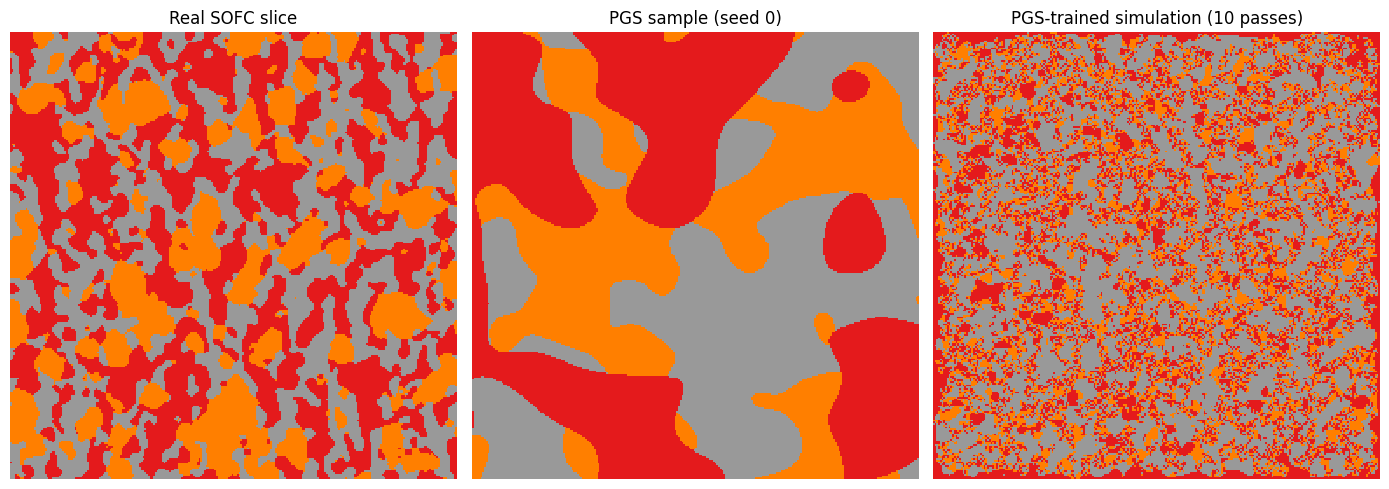


                           Real  PGS-trained
--------------------------------------------

Phase 0
  n_components              112         4133
  mean_diameter            16.9          2.4
  percolates              False        False

Phase 1
  n_components              186         4404
  mean_diameter            10.8          2.0
  percolates              False        False

Phase 2
  n_components              116         2757
  mean_diameter            16.1          3.9
  percolates              False        False


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pgs_tools import make_gaussian_fields, make_lithotype_map
from karnaugh_tools import build_table, sequential_simulate, compute_morphology

# Generate PGS training maps
n_realisations = 32
pgs_maps = []

for seed in range(n_realisations):
    f1, f2 = make_gaussian_fields(
        grid_size=256,
        len_scale_1=[30, 30], angles_1=[0, 0],
        len_scale_2=[20, 20], angles_2=[0, 0],
        seed_1=seed, seed_2=seed + 1000
    )
    litho = make_lithotype_map(f1, f2, Mat1=0.37, Mat2=0.28, Mat3=0.35)
    pgs_maps.append(litho)

print(f"Generated {len(pgs_maps)} PGS maps")
print(f"Map shape: {pgs_maps[0].shape}")
print(f"Mean proportions across realisations:")
for k in range(3):
    mean_prop = np.mean([np.mean(m == k) for m in pgs_maps])
    print(f"  Phase {k}: {mean_prop:.3f}")

# Build table from PGS maps
pairs = [(m, m) for m in pgs_maps]
table = build_table(pairs, neighbourhood='moore')
print(f"\nTable shape: {table.shape}")

# Simulate
rng = np.random.default_rng(42)
grid, history = sequential_simulate(
    table, shape=(256, 256),
    proportions=[0.37, 0.28, 0.35],
    rng=rng
)

# Visual comparison: PGS sample vs simulated vs real
import tifffile
raw = tifffile.imread('ThreePhase.tif')
remap = {0: 0, 128: 1, 255: 2}
volume = np.vectorize(remap.get)(raw).astype(np.uint8)
real_slice = volume[0]

cmap = plt.colormaps.get_cmap('Set1').resampled(3)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(real_slice, cmap=cmap, vmin=0, vmax=2, interpolation='nearest')
axes[0].set_title('Real SOFC slice')
axes[0].axis('off')
axes[1].imshow(pgs_maps[0], cmap=cmap, vmin=0, vmax=2, interpolation='nearest')
axes[1].set_title('PGS sample (seed 0)')
axes[1].axis('off')
axes[2].imshow(grid, cmap=cmap, vmin=0, vmax=2, interpolation='nearest')
axes[2].set_title(f'PGS-trained simulation ({len(history)} passes)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

# Morphology comparison
print(f"\n{'':20} {'Real':>10} {'PGS-trained':>12}")
print("-" * 44)
phase_names = ['Phase 0', 'Phase 1', 'Phase 2']
for phase, name in enumerate(phase_names):
    m_real = compute_morphology(real_slice)[phase]
    m_sim  = compute_morphology(grid)[phase]
    print(f"\n{name}")
    for metric in ['n_components', 'mean_diameter', 'percolates']:
        fmt = lambda v: f"{v:.1f}" if isinstance(v, float) else str(v)
        print(f"  {metric:18} {fmt(m_real[metric]):>10} {fmt(m_sim[metric]):>12}")

In [3]:
for ls in [5, 8, 12]:
    maps = []
    for seed in range(32):
        f1, f2 = make_gaussian_fields(
            grid_size=256,
            len_scale_1=[ls, ls], len_scale_2=[ls, ls],
            seed_1=seed, seed_2=seed+1000
        )
        maps.append(make_lithotype_map(f1, f2, Mat1=0.37, Mat2=0.28, Mat3=0.35))

    table = build_table([(m, m) for m in maps], neighbourhood='moore')
    rng = np.random.default_rng(42)
    grid, history = sequential_simulate(table, shape=(256,256), proportions=[0.37,0.28,0.35], rng=rng)
    m = compute_morphology(grid)
    print(f"len_scale={ls:2d}  passes={len(history)}  delta={history[-1]:.3f}  "
          f"diam=[{m[0]['mean_diameter']:.1f}, {m[1]['mean_diameter']:.1f}, {m[2]['mean_diameter']:.1f}]  "
          f"n_comp=[{m[0]['n_components']}, {m[1]['n_components']}, {m[2]['n_components']}]")

print(f"\nReal:              diam=[16.9, 10.8, 16.1]  n_comp=[112, 186, 116]")

Reached max passes (10)  (final δ = 0.0698)
len_scale= 5  passes=10  delta=0.070  diam=[12.2, 12.4, 17.4]  n_comp=[155, 166, 114]
Reached max passes (10)  (final δ = 0.0693)
len_scale= 8  passes=10  delta=0.069  diam=[8.4, 9.8, 21.3]  n_comp=[253, 240, 94]
Reached max passes (10)  (final δ = 0.1812)
len_scale=12  passes=10  delta=0.181  diam=[3.7, 3.5, 7.9]  n_comp=[1421, 1498, 730]

Real:              diam=[16.9, 10.8, 16.1]  n_comp=[112, 186, 116]
